In [1]:
!pip install -q faiss-cpu sentence-transformers transformers accelerate rank-bm25 gradio networkx scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 73.0 MB/s eta 0:00:00:00:0100:01


In [2]:
import pandas as pd
import numpy as np
import faiss
import time
import torch
import networkx as nx
import matplotlib.pyplot as plt

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

print("CUDA:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

CUDA: True
GPU count: 2


In [3]:
csv_path = "/kaggle/input/datasets/elkorachiinsaf/dataset-week4/professional_phishing_rag_dataset.csv"

df = pd.read_csv(csv_path)
df.head()

,id,text,label,attack_type,risk_level,language,source_type,contains_url,suspicious_keywords,explanation,synthetic_generated
0,1,Your order has been shipped successfully.,legitimate,normal,low,en,sms,0,none,No suspicious indicators detected. Message app...,1
1,2,Your CIH Bank account has been suspended. Veri...,phishing,banking,critical,en,url,1,"urgent, security, delivery","Contains urgency language, suspicious links, c...",1
2,3,تحذير عاجل: قم بتأكيد كلمة المرور الخاصة بك ال...,phishing,banking,critical,ar,url,1,"click, delivery, suspended","Contains urgency language, suspicious links, c...",1
3,4,Urgent! Confirm your password now to avoid acc...,phishing,job_scam,critical,en,url,1,"confirm, suspended, verify","Contains urgency language, suspicious links, c...",1
4,5,Vous avez gagné 2 BTC. Réclamez votre récompen...,phishing,banking,medium,fr,social_media,1,"confirm, suspended, bitcoin","Contains urgency language, suspicious links, c...",1


In [4]:
print(df.shape)
print(df.columns)
print(df["label"].value_counts())
print(df["language"].value_counts())
print(df["attack_type"].value_counts())

(500, 11)
Index(['id', 'text', 'label', 'attack_type', 'risk_level', 'language',
       'source_type', 'contains_url', 'suspicious_keywords', 'explanation',
       'synthetic_generated'],
      dtype='object')
label
phishing      288
legitimate    212
Name: count, dtype: int64
language
fr    190
en    158
ar    152
Name: count, dtype: int64
attack_type
normal              212
social_media         52
crypto_scam          44
credential_theft     42
delivery             41
fake_support         37
job_scam             36
banking              36
Name: count, dtype: int64


In [5]:
df = df.fillna("unknown")

documents = []

for _, row in df.iterrows():
    doc = f"""
    Message: {row['text']}
    Label: {row['label']}
    Attack Type: {row['attack_type']}
    Risk Level: {row['risk_level']}
    Language: {row['language']}
    Source Type: {row['source_type']}
    Contains URL: {row['contains_url']}
    Suspicious Keywords: {row['suspicious_keywords']}
    Explanation: {row['explanation']}
    """
    documents.append(doc)

print("Documents:", len(documents))
print(documents[0])

Documents: 500

    Message: Your order has been shipped successfully.
    Label: legitimate
    Attack Type: normal
    Risk Level: low
    Language: en
    Source Type: sms
    Contains URL: 0
    Suspicious Keywords: none
    Explanation: No suspicious indicators detected. Message appears legitimate and informational.
    


In [6]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

doc_embeddings = embedding_model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
)

doc_embeddings.shape

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

(500, 384)

In [7]:
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings.astype("float32"))

print("Indexed vectors:", index.ntotal)

Indexed vectors: 500


In [8]:
def retrieve(query, k=3):
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")

    distances, indices = index.search(query_embedding, k)

    results = []
    for idx, dist in zip(indices[0], distances[0]):
        results.append({
            "index": int(idx),
            "document": documents[idx],
            "distance": float(dist),
            "label": df.iloc[idx]["label"],
            "attack_type": df.iloc[idx]["attack_type"],
            "risk_level": df.iloc[idx]["risk_level"]
        })

    return results

In [9]:
query = "Your PayPal account has been suspended. Verify your password now."

results = retrieve(query, k=3)

for r in results:
    print("Index:", r["index"])
    print("Label:", r["label"])
    print("Attack:", r["attack_type"])
    print("Risk:", r["risk_level"])
    print(r["document"])
    print("-" * 80)

Index: 479
Label: phishing
Attack: banking
Risk: medium

    Message: Your PayPal account has been suspended. Verify immediately: https://robinson.info/
    Label: phishing
    Attack Type: banking
    Risk Level: medium
    Language: en
    Source Type: sms
    Contains URL: 1
    Suspicious Keywords: click, bitcoin, password
    Explanation: Contains urgency language, suspicious links, credential request, or impersonation indicators.
    
--------------------------------------------------------------------------------
Index: 183
Label: phishing
Attack: fake_support
Risk: medium

    Message: Your PayPal account has been suspended. Verify immediately: https://hernandez.com/
    Label: phishing
    Attack Type: fake_support
    Risk Level: medium
    Language: en
    Source Type: email
    Contains URL: 1
    Suspicious Keywords: confirm, click, suspended
    Explanation: Contains urgency language, suspicious links, credential request, or impersonation indicators.
    
----------------

In [10]:
llm = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=200,
    do_sample=False,
    return_full_text=False
)

def generate_answer(prompt, max_new_tokens=200):
    output = llm(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False
    )
    return output[0]["generated_text"].strip()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [11]:
def llm_no_rag(query):
    prompt = f"""
    You are a cybersecurity assistant.

    Analyze this message and classify it as phishing or legitimate.
    Also explain briefly why.

    Message:
    {query}

    Answer format:
    Classification:
    Risk:
    Explanation:
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": []
    }

In [12]:
def rag_classic(query, k=3):
    retrieved = retrieve(query, k)

    context = "\n".join([r["document"] for r in retrieved])

    prompt = f"""
    You are a cybersecurity phishing detection assistant.

    Use ONLY the following retrieved examples to analyze the message.

    Retrieved examples:
    {context}

    User message:
    {query}

    Provide:
    1. Classification: phishing or legitimate
    2. Risk level: low, medium, high, critical
    3. Suspicious indicators
    4. Recommendation
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": retrieved
    }

In [13]:
reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

def rag_rerank(query, initial_k=8, final_k=3):
    retrieved = retrieve(query, initial_k)

    docs = [r["document"] for r in retrieved]
    pairs = [[query, doc] for doc in docs]

    scores = reranker.predict(pairs)

    ranked = sorted(
        zip(retrieved, scores),
        key=lambda x: x[1],
        reverse=True
    )

    final_docs = [x[0] for x in ranked[:final_k]]
    context = "\n".join([r["document"] for r in final_docs])

    prompt = f"""
    You are a cybersecurity phishing detection assistant.

    Use the most relevant re-ranked examples below.

    Context:
    {context}

    Message:
    {query}

    Return:
    Classification:
    Risk:
    Attack type:
    Explanation:
    Recommendation:
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": final_docs
    }

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [14]:
tokenized_docs = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_docs)

def hybrid_retrieve(query, k=3):
    dense_results = retrieve(query, k)

    bm25_scores = bm25.get_scores(query.lower().split())
    top_bm25_indices = np.argsort(bm25_scores)[::-1][:k]

    merged = {}

    for r in dense_results:
        merged[r["index"]] = r

    for idx in top_bm25_indices:
        merged[int(idx)] = {
            "index": int(idx),
            "document": documents[idx],
            "distance": float(bm25_scores[idx]),
            "label": df.iloc[idx]["label"],
            "attack_type": df.iloc[idx]["attack_type"],
            "risk_level": df.iloc[idx]["risk_level"]
        }

    return list(merged.values())[:k]


def rag_hybrid(query, k=3):
    retrieved = hybrid_retrieve(query, k)

    context = "\n".join([r["document"] for r in retrieved])

    prompt = f"""
    You are a professional phishing detection assistant.

    Use semantic and keyword-based retrieved examples.

    Context:
    {context}

    Message:
    {query}

    Analyze:
    - phishing or legitimate
    - risk level
    - attack type
    - suspicious keywords
    - URL risk
    - final recommendation
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": retrieved
    }

In [15]:
def multi_hop_rag(query):
    first_docs = retrieve(query, k=3)

    reformulated_query = query + " phishing scam suspicious urgent password account link fraud"
    second_docs = hybrid_retrieve(reformulated_query, k=3)

    all_docs = first_docs + second_docs

    unique_docs = {}
    for d in all_docs:
        unique_docs[d["index"]] = d

    final_docs = list(unique_docs.values())[:4]

    context = "\n".join([r["document"] for r in final_docs])

    prompt = f"""
    You are a cybersecurity analyst.

    First, analyze the message.
    Then compare it with similar phishing and legitimate examples.

    Context:
    {context}

    Message:
    {query}

    Return a detailed phishing analysis:
    Classification:
    Risk:
    Evidence:
    Similar cases:
    Recommendation:
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": final_docs
    }

In [16]:
G = nx.Graph()

for i, row in df.iterrows():
    msg_node = f"msg_{row['id']}"

    G.add_node(msg_node, type="message")

    for col in ["label", "attack_type", "risk_level", "language", "source_type"]:
        value = str(row[col])
        G.add_node(value, type=col)
        G.add_edge(msg_node, value)

    keywords = str(row["suspicious_keywords"]).split(",")
    for kw in keywords:
        kw = kw.strip().lower()
        if kw and kw != "none":
            G.add_node(kw, type="keyword")
            G.add_edge(msg_node, kw)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 528
Edges: 3330


In [17]:
def graph_rag(query):
    query_words = query.lower().split()

    matched_nodes = []
    for word in query_words:
        if word in G.nodes:
            matched_nodes.append(word)

    related_msg_ids = set()

    for node in matched_nodes:
        for neighbor in G.neighbors(node):
            if str(neighbor).startswith("msg_"):
                related_msg_ids.add(neighbor)

    graph_docs = []

    for msg_node in list(related_msg_ids)[:3]:
        msg_id = int(msg_node.replace("msg_", ""))
        row_index = df[df["id"] == msg_id].index[0]

        graph_docs.append({
            "index": int(row_index),
            "document": documents[row_index],
            "distance": 0.0,
            "label": df.iloc[row_index]["label"],
            "attack_type": df.iloc[row_index]["attack_type"],
            "risk_level": df.iloc[row_index]["risk_level"]
        })

    if len(graph_docs) == 0:
        graph_docs = hybrid_retrieve(query, k=3)

    context = "\n".join([r["document"] for r in graph_docs])

    prompt = f"""
    You are a phishing detection assistant using a knowledge graph.

    Graph-based context:
    {context}

    Message:
    {query}

    Give:
    Classification:
    Risk:
    Related indicators:
    Explanation:
    Recommendation:
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": graph_docs
    }

In [18]:
def agentic_rag(query):
    q = query.lower()

    phishing_signals = [
        "urgent", "verify", "password", "suspended", "click",
        "login", "account", "bitcoin", "reward", "bank",
        "colis", "bloqué", "mot de passe", "compte",
        "عاجل", "كلمة المرور", "حسابك", "اضغط"
    ]

    has_signal = any(signal in q for signal in phishing_signals)
    has_url = "http" in q or "www" in q or ".com" in q or ".net" in q

    if has_signal or has_url:
        retrieved = hybrid_retrieve(query, k=3)
        strategy = "Hybrid Retrieval activated"
    else:
        retrieved = retrieve(query, k=2)
        strategy = "Light semantic retrieval"

    context = "\n".join([r["document"] for r in retrieved])

    prompt = f"""
    You are an agentic cybersecurity assistant.

    Strategy:
    {strategy}

    Context:
    {context}

    Message:
    {query}

    Decide step by step:
    1. Is retrieval needed?
    2. Is the message phishing?
    3. What is the risk level?
    4. What indicators justify the decision?
    5. What should the user do?

    Final answer:
    """

    return {
        "answer": generate_answer(prompt),
        "retrieved_docs": retrieved,
        "strategy": strategy
    }

In [19]:
test_message = "Urgent! Your PayPal account has been suspended. Verify your password here: http://paypal-security-reset.com"

for name, func in {
    "Baseline": llm_no_rag,
    "Classic RAG": rag_classic,
    "Rerank RAG": rag_rerank,
    "Hybrid RAG": rag_hybrid,
    "Multi-hop RAG": multi_hop_rag,
    "Graph RAG": graph_rag,
    "Agentic RAG": agentic_rag
}.items():
    print("=" * 80)
    print(name)
    result = func(test_message)
    print(result["answer"])

Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Baseline


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Message:
    Dear valued customer,

    We are writing to inform you that your PayPal account has been suspended due to a security breach. We have taken immediate action to investigate the issue and are working to restore your account as soon as possible.

    In the meantime, please visit the website provided in the message to verify your account and reset your password. If you have any questions or concerns, please do not hesitate to contact our customer support team.

    Thank you for your cooperation.

    Best regards,
    [Your Name]

    PayPal Security Reset URL: [Insert URL]

    Message:
    Dear valued customer,

    We are writing to inform you that your PayPal account has been suspended due to a security breach. We have taken immediate action to investigate the issue and are working to restore your account as soon as possible.
Classic RAG


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Example:
    - Phishing: Risk Level: Medium, Attack Type: Banking, Suspicious Keywords: click, bitcoin, password
    - Legitimate: Risk Level: Low, Attack Type: Crypto_Scam, Suspicious Keywords: click, urgent, security
    - Phishing: Risk Level: High, Attack Type: Crypto_Scam, Suspicious Keywords: click, urgent, security
    - Legitimate: Risk Level: Medium, Attack Type: Fake_Support, Suspicious Keywords: confirm, click, suspended
    - Phishing: Risk Level: High, Attack Type: Banking, Suspicious Keywords: click, bitcoin, password
    - Legitimate: Risk Level: Low, Attack Type: Banking, Suspicious Keywords: click
Multi-hop RAG


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Message:
    Your PayPal account has been suspended. Verify your PayPal account here: https://robinson.info/

    Return a detailed phishing analysis:
    Classification:
    Risk:
    Evidence:
    Similar cases:
    Recommendation:
    
    Message:
    Your PayPal account has been suspended. Verify your PayPal account here: https://tucker.com/

    Return a detailed phishing analysis:
    Classification:
    Risk:
    Evidence:
    Similar cases:
    Recommendation:
    
    Message:
    Your PayPal account has been suspended. Verify your PayPal account here: https://hernandez.com/

    Return a detailed phishing analysis:
    Classification:
    Risk:
    Evidence:
    Similar cases:
Graph RAG


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Message:
    Urgent! Your PayPal account has been suspended. Verify your password here: http://paypal-security-reset.com

    Give:
    Classification:
    Risk:
    Related indicators:
    Explanation:
    Recommendation:
    
    Message:
    Urgent! Your PayPal account has been suspended. Verify your password here: http://paypal-security-reset.com

    Give:
    Classification:
    Risk:
    Related indicators:
    Explanation:
    Recommendation:
    
    Message:
    Urgent! Your PayPal account has been suspended. Verify your password here: http://paypal-security-reset.com

    Give:
    Classification:
    Risk:
    Related indicators:
    Explanation
Agentic RAG
1. No retrieval needed
    2. Medium risk level
    3. Urgent indicators: click, suspicious links, credential request, or impersonation.
    4. User should verify their password.
    5. Follow the link to verify their password.


In [20]:
def precision_at_k(retrieved_indices, relevant_indices, k):
    retrieved_k = retrieved_indices[:k]
    return len(set(retrieved_k).intersection(set(relevant_indices))) / k


def recall_at_k(retrieved_indices, relevant_indices, k):
    retrieved_k = retrieved_indices[:k]

    if len(relevant_indices) == 0:
        return 0

    return len(set(retrieved_k).intersection(set(relevant_indices))) / len(relevant_indices)


def mrr_score(retrieved_indices, relevant_indices):
    for rank, idx in enumerate(retrieved_indices, start=1):
        if idx in relevant_indices:
            return 1 / rank
    return 0


def semantic_similarity(text1, text2):
    emb1 = embedding_model.encode([text1])
    emb2 = embedding_model.encode([text2])
    return cosine_similarity(emb1, emb2)[0][0]

In [25]:
test_queries = []

sample_df = df.sample(12, random_state=42)

for idx, row in sample_df.iterrows():
    test_queries.append({
        "query": row["text"],
        "expected_label": row["label"],
        "expected_attack_type": row["attack_type"],
        "expected_risk_level": row["risk_level"]
    })

test_queries[:3]

[{'query': 'You won 2 BTC. Claim your reward here: https://hawkins.info/',
  'expected_label': 'phishing',
  'expected_attack_type': 'crypto_scam',
  'expected_risk_level': 'high'},
 {'query': 'Votre rendez-vous est prévu demain à 10h.',
  'expected_label': 'legitimate',
  'expected_attack_type': 'normal',
  'expected_risk_level': 'low'},
 {'query': 'تحذير عاجل: قم بتأكيد كلمة المرور الخاصة بك الآن: http://james.com/',
  'expected_label': 'phishing',
  'expected_attack_type': 'credential_theft',
  'expected_risk_level': 'critical'}]

In [26]:
architectures = {
    "Baseline LLM": llm_no_rag,
    "Classic RAG": rag_classic,
    "Rerank RAG": rag_rerank,
    "Hybrid RAG": rag_hybrid,
    "Multi-hop RAG": multi_hop_rag,
    "Graph RAG": graph_rag,
    "Agentic RAG": agentic_rag
}

evaluation_results = []

for arch_name, arch_func in architectures.items():
    for item in test_queries:
        query = item["query"]
        expected_label = item["expected_label"]
        expected_attack = item["expected_attack_type"]
        expected_risk = item["expected_risk_level"]

        start = time.time()
        output = arch_func(query)
        latency = time.time() - start

        retrieved_docs = output.get("retrieved_docs", [])

        if len(retrieved_docs) > 0:
            label_matches = [
                1 if doc["label"] == expected_label else 0
                for doc in retrieved_docs[:3]
            ]

            attack_matches = [
                1 if doc["attack_type"] == expected_attack else 0
                for doc in retrieved_docs[:3]
            ]

            risk_matches = [
                1 if doc["risk_level"] == expected_risk else 0
                for doc in retrieved_docs[:3]
            ]

            precision_at_3 = sum(label_matches) / 3
            attack_accuracy = sum(attack_matches) / 3
            risk_accuracy = sum(risk_matches) / 3

            mrr = 0
            for rank, match in enumerate(label_matches, start=1):
                if match == 1:
                    mrr = 1 / rank
                    break
        else:
            precision_at_3 = 0
            attack_accuracy = 0
            risk_accuracy = 0
            mrr = 0

        evaluation_results.append({
            "Architecture": arch_name,
            "Query": query,
            "Precision@3": precision_at_3,
            "AttackType@3": attack_accuracy,
            "RiskLevel@3": risk_accuracy,
            "MRR": mrr,
            "Latency": latency
        })

results_df = pd.DataFrame(evaluation_results)
results_df

Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

,Architecture,Query,Precision@3,AttackType@3,RiskLevel@3,MRR,Latency
0,Baseline LLM,You won 2 BTC. Claim your reward here: https:/...,0.0,0.000000,0.000000,0.0,7.452258
1,Baseline LLM,Votre rendez-vous est prévu demain à 10h.,0.0,0.000000,0.000000,0.0,7.470846
2,Baseline LLM,تحذير عاجل: قم بتأكيد كلمة المرور الخاصة بك ال...,0.0,0.000000,0.000000,0.0,7.442548
3,Baseline LLM,موعدك غداً على الساعة العاشرة صباحاً.,0.0,0.000000,0.000000,0.0,7.563672
4,Baseline LLM,شكراً على عملية الشراء الأخيرة.,0.0,0.000000,0.000000,0.0,7.610745
...,...,...,...,...,...,...,...
79,Agentic RAG,Votre colis est bloqué. Cliquez ici : https://...,1.0,0.666667,0.000000,1.0,2.648980
80,Agentic RAG,Your Amazon account has been suspended. Verify...,1.0,0.333333,0.333333,1.0,3.046071
81,Agentic RAG,Urgent ! Confirmez votre mot de passe maintena...,1.0,0.000000,0.000000,1.0,2.495494
82,Agentic RAG,تحذير عاجل: قم بتأكيد كلمة المرور الخاصة بك ال...,1.0,0.333333,0.666667,1.0,7.544737


In [27]:
summary_df = results_df.groupby("Architecture").mean(numeric_only=True).reset_index()
summary_df

,Architecture,Precision@3,AttackType@3,RiskLevel@3,MRR,Latency
0,Agentic RAG,0.833333,0.277778,0.444444,0.916667,5.740608
1,Baseline LLM,0.000000,0.000000,0.000000,0.000000,7.522889
2,Classic RAG,0.916667,0.361111,0.527778,0.916667,7.465469
3,Graph RAG,0.916667,0.388889,0.555556,0.916667,7.584947
4,Hybrid RAG,0.916667,0.361111,0.527778,0.916667,7.191640
5,Multi-hop RAG,0.916667,0.361111,0.527778,0.916667,7.718514
6,Rerank RAG,0.916667,0.388889,0.527778,0.916667,7.672877


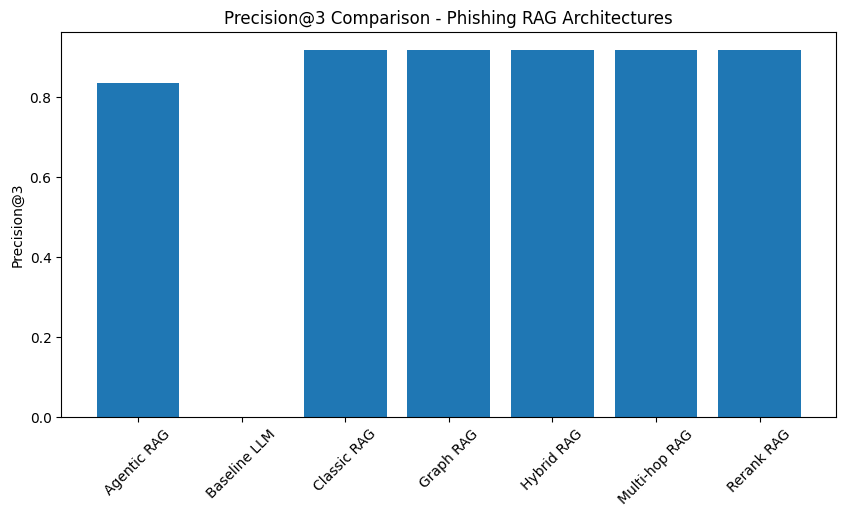

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["Architecture"], summary_df["Precision@3"])
plt.xticks(rotation=45)
plt.title("Precision@3 Comparison - Phishing RAG Architectures")
plt.ylabel("Precision@3")
plt.show()

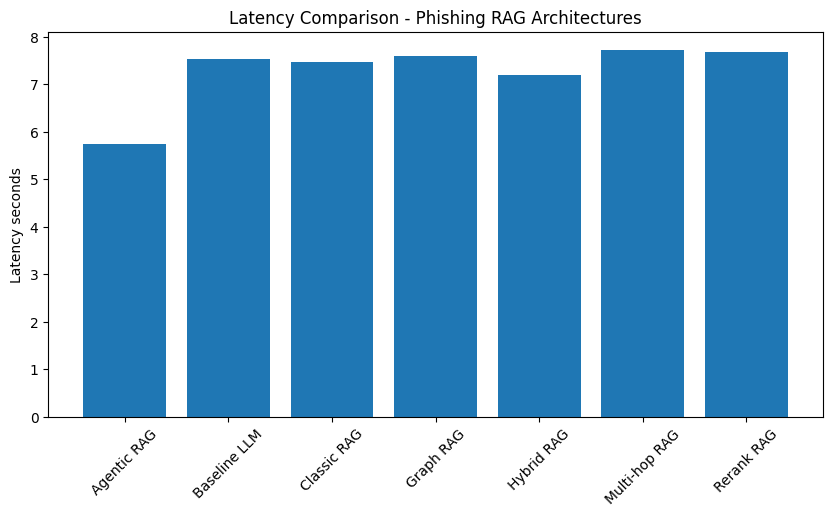

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["Architecture"], summary_df["Latency"])
plt.xticks(rotation=45)
plt.title("Latency Comparison - Phishing RAG Architectures")
plt.ylabel("Latency seconds")
plt.show()

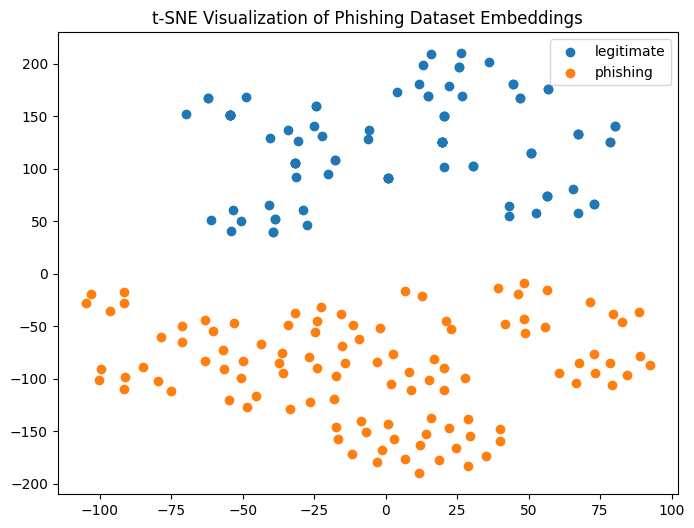

In [30]:
sample_size = min(200, len(doc_embeddings))
sample_embeddings = doc_embeddings[:sample_size]
sample_labels = df["label"].iloc[:sample_size].values

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

reduced = tsne.fit_transform(sample_embeddings)

plt.figure(figsize=(8, 6))

for label in set(sample_labels):
    idxs = [i for i, l in enumerate(sample_labels) if l == label]
    plt.scatter(reduced[idxs, 0], reduced[idxs, 1], label=label)

plt.title("t-SNE Visualization of Phishing Dataset Embeddings")
plt.legend()
plt.show()

In [31]:
import gradio as gr

def gradio_chat(message, architecture):
    if architecture == "Baseline LLM":
        result = llm_no_rag(message)
    elif architecture == "Classic RAG":
        result = rag_classic(message)
    elif architecture == "Rerank RAG":
        result = rag_rerank(message)
    elif architecture == "Hybrid RAG":
        result = rag_hybrid(message)
    elif architecture == "Multi-hop RAG":
        result = multi_hop_rag(message)
    elif architecture == "Graph RAG":
        result = graph_rag(message)
    else:
        result = agentic_rag(message)

    retrieved_text = "\n\n".join(
        [doc["document"] for doc in result.get("retrieved_docs", [])]
    )

    return result["answer"], retrieved_text


demo = gr.Interface(
    fn=gradio_chat,
    inputs=[
        gr.Textbox(
            label="Suspicious Message / Email / SMS / URL",
            placeholder="Paste a suspicious message here..."
        ),
        gr.Dropdown(
            choices=[
                "Baseline LLM",
                "Classic RAG",
                "Rerank RAG",
                "Hybrid RAG",
                "Multi-hop RAG",
                "Graph RAG",
                "Agentic RAG"
            ],
            value="Hybrid RAG",
            label="RAG Architecture"
        )
    ],
    outputs=[
        gr.Textbox(label="Phishing Analysis"),
        gr.Textbox(label="Retrieved Similar Cases")
    ],
    title="Phishing Detection and Analysis using RAG",
    description="Multilingual phishing detection system using personal dataset, FAISS, BM25, GraphRAG and Agentic RAG."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a1dd867b236621a299.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
